### Portfolio Optimization and VaR (Value at Risk)  Analysis

Objective
- Fetch daily stock data from Yahoo finance
- Calculate historical returns
- Compute Value at Risk (VaR) using different methods
- Optimize portfolio allocation to minimize VaR

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.optimize as optimize
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# random seed and style for visualizations
np.random.seed(42)
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

### Fetching stock data using yfinance

In [ ]:
tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'BNB-USD']

# Fetch historical stock data
def fetch_stock_data(tickers, start_date='2023-01-01', end_date='2024-01-01'):
    #data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    data = yf.download(tickers, start=start_date, end=end_date)['Close']
    return data

[*********************100%***********************]  4 of 4 completed


<Figure size 1200x600 with 0 Axes>

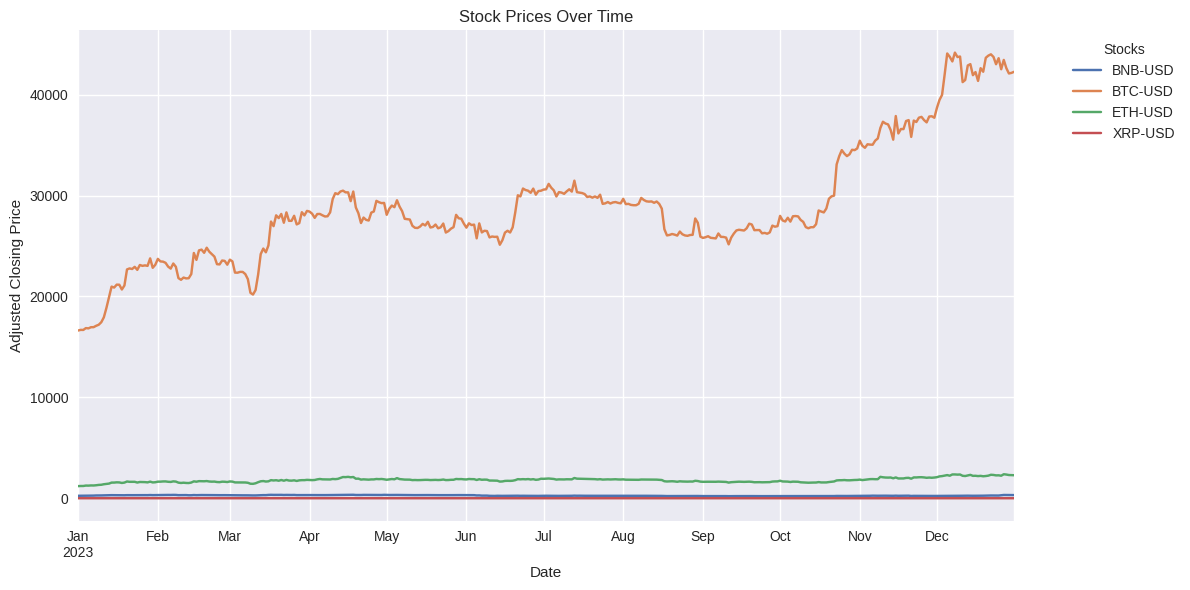

In [ ]:
stock_data = fetch_stock_data(tickers)

# Visualize Stock Prices
plt.figure(figsize=(12, 6))
stock_data.plot(title='Stock Prices Over Time', figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price')
plt.legend(title='Stocks', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Calculating Returns for the fetched prices

In [ ]:
# Calculate daily returns
def calculate_returns(prices):
    returns = np.log(prices / prices.shift(1))
    return returns.dropna()

stock_returns = calculate_returns(stock_data)

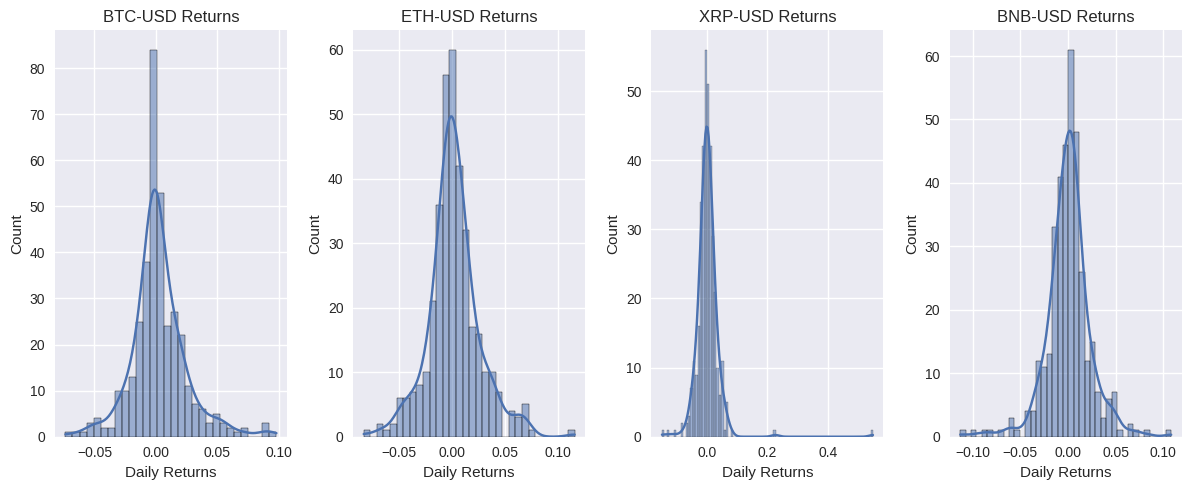


Descriptive Statistics of Returns:
Ticker     BNB-USD     BTC-USD     ETH-USD     XRP-USD
count   364.000000  364.000000  364.000000  364.000000
mean      0.000678    0.002563    0.001763    0.001638
std       0.023449    0.022685    0.024310    0.041622
min      -0.113212   -0.073624   -0.083263   -0.148494
25%      -0.010265   -0.007489   -0.009662   -0.013696
50%       0.001487   -0.000008    0.000152    0.000237
75%       0.010437    0.013030    0.012676    0.014488
max       0.108540    0.098123    0.115462    0.548555


In [ ]:
# Plot Returns Distribution
plt.figure(figsize=(15, 5))

for i, ticker in enumerate(tickers, 1):
    plt.subplot(1, 5, i)
    sns.histplot(stock_returns[ticker], kde=True)
    plt.title(f'{ticker} Returns')
    plt.xlabel('Daily Returns')

plt.tight_layout()
plt.show()

# Descriptions
print("\nDescriptive Statistics of Returns:")
print(stock_returns.describe())

### VaR Calculation

In [ ]:
# VaR Calculation with different methods
class VaRCalculator:
    @staticmethod
    def historical_simulation_var(returns, confidence_level=0.95, initial_investment=100000):
        var = np.percentile(returns, (1 - confidence_level) * 100) * initial_investment
        return abs(var)

    @staticmethod
    def parametric_var(returns, confidence_level=0.95, initial_investment=100000):
        mean = np.mean(returns)
        std_dev = np.std(returns)
        z_score = stats.norm.ppf(1 - confidence_level)
        var = (mean + z_score * std_dev) * initial_investment
        return abs(var)

    @staticmethod
    def monte_carlo_var(returns, num_simulations=10000, confidence_level=0.95, initial_investment=100000):
        mean = np.mean(returns)
        std_dev = np.std(returns)

        simulated_returns = np.random.normal(
            mean, std_dev, num_simulations
        ) * initial_investment

        var = np.percentile(simulated_returns, (1 - confidence_level) * 100)
        return abs(var)

In [ ]:
# Calculate VaR for individual stocks using different methods
var_methods = {
    'Historical Simulation': VaRCalculator.historical_simulation_var,
    'Parametric (Variance-Covariance)': VaRCalculator.parametric_var,
    'Monte Carlo Simulation': VaRCalculator.monte_carlo_var
}

# VaR Calculation with different methods
var_results = {}
for method_name, method in var_methods.items():
    var_results[method_name] = {}
    for ticker in tickers:
        var_results[method_name][ticker] = method(stock_returns[ticker])

<Figure size 1200x600 with 0 Axes>

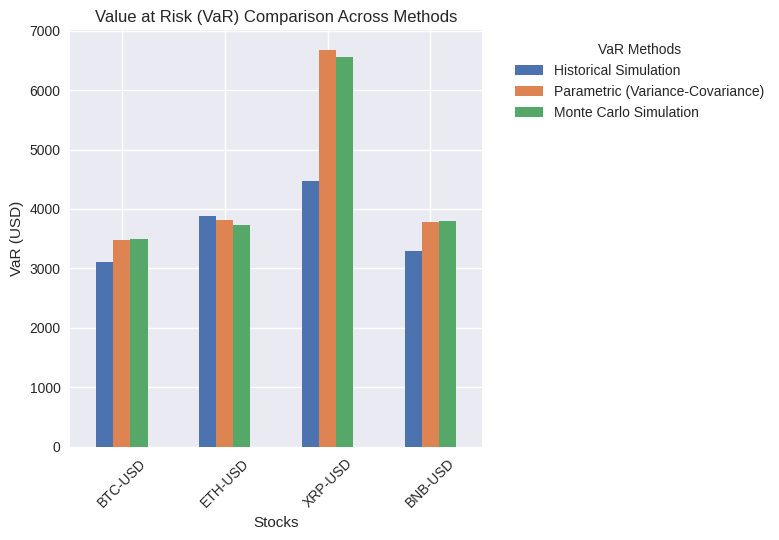


Value at Risk (95% Confidence) Comparison:

Historical Simulation Method:
BTC-USD: $3109.77
ETH-USD: $3878.69
XRP-USD: $4469.81
BNB-USD: $3288.94

Parametric (Variance-Covariance) Method:
BTC-USD: $3469.84
ETH-USD: $3816.81
XRP-USD: $6672.97
BNB-USD: $3783.89

Monte Carlo Simulation Method:
BTC-USD: $3492.51
ETH-USD: $3730.55
XRP-USD: $6557.09
BNB-USD: $3797.30


In [ ]:
# Plot VaR calculated with different methods
plt.figure(figsize=(12, 6))
var_df = pd.DataFrame(var_results)
var_df.plot(kind='bar', rot=45)
plt.title('Value at Risk (VaR) Comparison Across Methods')
plt.xlabel('Stocks')
plt.ylabel('VaR (USD)')
plt.legend(title='VaR Methods', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print VaR Results
print("\nValue at Risk (95% Confidence) Comparison:")
for method, results in var_results.items():
    print(f"\n{method} Method:")
    for ticker, var in results.items():
        print(f"{ticker}: ${var:.2f}")

### Optimizing Portfolio
(the tickers mentioned at the starting are the portfolio stocks)

In [ ]:
# Portfolio Optimization Function
def portfolio_var(weights, returns):
    portfolio_returns = returns @ weights
    return np.percentile(portfolio_returns, 5)  # calculating for 95% VaR

def optimization_constraints(weights):
    return np.sum(weights) - 1.0  # Weights must sum to 1

num_stocks = len(tickers)
initial_weights = np.array([1/num_stocks] * num_stocks)

bounds = tuple((0, 1) for _ in range(num_stocks))

# Optimization
optimization_result = optimize.minimize(
    portfolio_var,
    initial_weights,
    args=(stock_returns.values,),
    method='SLSQP',
    bounds=bounds,
    constraints={'type': 'eq', 'fun': optimization_constraints}
)

# Optimal Weights
optimal_weights = optimization_result.x
rounded_weights = np.round(optimal_weights, 2)

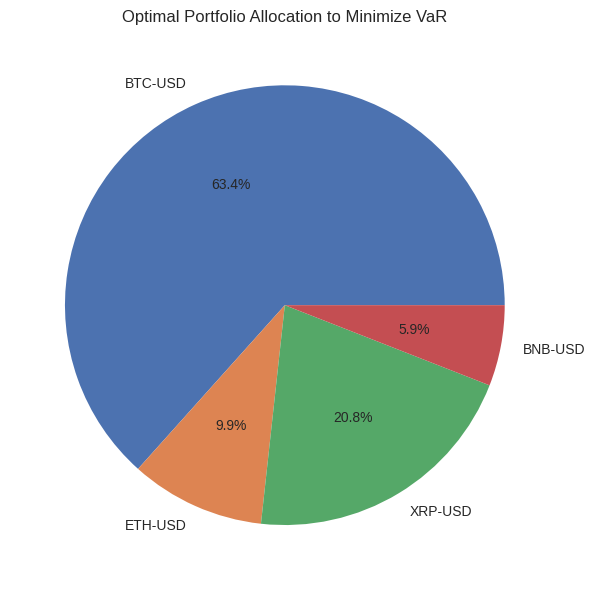


Optimal Portfolio Weights:
BTC-USD: 0.6379
ETH-USD: 0.0963
XRP-USD: 0.2108
BNB-USD: 0.0551

Optimized Portfolio VaR: 0.04


In [ ]:
# Plot in Pie Chart
plt.figure(figsize=(10, 6))
plt.pie(rounded_weights, labels=tickers, autopct='%1.1f%%')
plt.title('Optimal Portfolio Allocation to Minimize VaR')
plt.tight_layout()
plt.show()

print("\nOptimal Portfolio Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")


print(f"\nOptimized Portfolio VaR: {-portfolio_var(optimal_weights, stock_returns.values):.2f}")

### VaR Calculation Methods Explanation

#### 1. Historical Simulation Method
- Uses actual historical returns distribution
- No assumptions about return distribution
- Directly uses empirical returns data
- Computationally simple

#### 2. Parametric (Variance-Covariance) Method
- Assumes returns follow a normal distribution
- Uses mean and standard deviation
- Parametric approach with statistical parameters
- Simple but may not capture extreme events

#### 3. Monte Carlo Simulation Method
- Generates multiple random return scenarios
- Based on statistical properties of returns
- More flexible and can model complex distributions
- Computationally intensive

#### Interpretation
- Compares three different VaR calculation methods
- Each method has strengths and limitations
- Choice depends on specific investment context

#### Limitations
- Relies on historical data
- Assumes past performance reflects future behavior
- Does not account for unexpected market events